# Modelos Predictivos — Regresión de Salarios

[![francomansilla.com](https://img.shields.io/badge/francomansilla.com-555555?style=flat&logo=globe&logoColor=white)](https://www.francomansilla.com)

Este notebook compara tres modelos de regresión para predecir salarios a partir de variables socioeconómicas: MCO (regresión lineal clásica), Random Forest y Gradient Boosting. Se evalúan en un conjunto de validación (30%), se optimizan los hiperparámetros del mejor modelo con `RandomizedSearchCV`, y finalmente se entrena con toda la base para generar predicciones en casos nuevos.

<br>

**Librerías**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat&logo=numpy&logoColor=white)](https://numpy.org/doc/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)
[![statsmodels](https://img.shields.io/badge/statsmodels-4B8BBE?style=flat&logo=python&logoColor=white)](https://www.statsmodels.org/stable/index.html)

**Modelos y métodos**

[![OLS](https://img.shields.io/badge/OLS_(MCO)-0078D4?style=flat&logo=python&logoColor=white)](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)
[![RandomForest](https://img.shields.io/badge/Random_Forest-2E8B57?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
[![GradientBoosting](https://img.shields.io/badge/Gradient_Boosting-E34F26?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
[![RandomizedSearchCV](https://img.shields.io/badge/RandomizedSearchCV-6A0DAD?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

**Métricas**

[![RMSE](https://img.shields.io/badge/RMSE-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
[![R²](https://img.shields.io/badge/R²-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/fmansillaib/umayor_class/main/datasets/datos_transversales_paneles/determinantes_salario/datos.csv')

# Convierte comas decimales en columnas object (ej. '21,63') a valores numéricos
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

df

,salario,educ,exper,perm,marr,#dep,nort,sur,oeste
0,21.63,18,8,8,0,0,0,0,0
1,4.50,12,37,14,1,0,0,0,1
2,3.50,12,31,3,0,1,0,0,1
3,2.90,6,49,7,1,0,0,1,0
4,2.54,9,2,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...
521,5.11,11,3,0,0,0,0,0,1
522,7.25,12,14,5,1,3,0,0,1
523,2.92,3,11,30,0,0,0,1,0
524,6.33,12,23,8,1,2,0,1,0


In [8]:
df_entrenamiento, df_validacion = train_test_split(df, test_size=0.30, random_state=42)
df_entrenamiento = df_entrenamiento.reset_index(drop=True)
df_validacion    = df_validacion.reset_index(drop=True)

print(f"Entrenamiento: {len(df_entrenamiento)} filas")
print(f"Validación:    {len(df_validacion)} filas")


Entrenamiento: 368 filas
Validación:    158 filas


## Regresión MCO (Mínimos Cuadrados Ordinarios)

Variable dependiente: `salario`. Predictoras: `educ`, `exper`, `perm`, `marr`, `#dep`, `nort`, `sur`, `oeste`.


In [9]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_train = sm.add_constant(df_entrenamiento[features])
y_train = df_entrenamiento['salario']

X_test = sm.add_constant(df_validacion[features])
y_test = df_validacion['salario']

# Ajuste MCO
modelo_mco = sm.OLS(y_train, X_train).fit()
print(modelo_mco.summary())

# Evaluación en validación
y_pred = modelo_mco.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"\n--- Validación ---")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


                            OLS Regression Results                            
Dep. Variable:                salario   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     22.00
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.90e-27
Time:                        21:39:20   Log-Likelihood:                -907.92
No. Observations:                 368   AIC:                             1834.
Df Residuals:                     359   BIC:                             1869.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2589      0.876     -2.579      0.0

## Random Forest

Modelo de ensamble basado en árboles de decisión. Variable dependiente: `salario`. Mismas predictoras que MCO.


In [10]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_train = df_entrenamiento[features]
y_train = df_entrenamiento['salario']

X_test = df_validacion[features]
y_test = df_validacion['salario']

# Ajuste Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Evaluación en validación
y_pred_rf = modelo_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest (Validación) ---")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

# Importancia de variables
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)
print(f"\nImportancia de variables:")
print(importancias.to_string())


--- Random Forest (Validación) ---
RMSE : 3.0673
R²   : 0.3010

Importancia de variables:
perm     0.334868
educ     0.243465
exper    0.218553
#dep     0.080621
marr     0.040626
oeste    0.036040
sur      0.023829
nort     0.021997


## Gradient Boosting

Modelo de boosting que construye árboles de forma secuencial minimizando el error residual. Variable dependiente: `salario`. Mismas predictoras que los modelos anteriores.


In [11]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_train = df_entrenamiento[features]
y_train = df_entrenamiento['salario']

X_test = df_validacion[features]
y_test = df_validacion['salario']

# Ajuste Gradient Boosting
modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
modelo_gb.fit(X_train, y_train)

# Evaluación en validación
y_pred_gb = modelo_gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print(f"--- Gradient Boosting (Validación) ---")
print(f"RMSE : {rmse_gb:.4f}")
print(f"R²   : {r2_gb:.4f}")

# Importancia de variables
importancias_gb = pd.Series(modelo_gb.feature_importances_, index=features).sort_values(ascending=False)
print(f"\nImportancia de variables:")
print(importancias_gb.to_string())


--- Gradient Boosting (Validación) ---
RMSE : 3.0722
R²   : 0.2988

Importancia de variables:
perm     0.405511
educ     0.289016
exper    0.176845
#dep     0.055205
marr     0.051720
oeste    0.012997
sur      0.008307
nort     0.000398


## Resumen Comparativo de Modelos


In [12]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_train = df_entrenamiento[features]
y_train = df_entrenamiento['salario']
X_test  = df_validacion[features]
y_test  = df_validacion['salario']

# MCO - predicciones en train
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
y_pred_mco_train = modelo_mco.predict(X_train_sm)
y_pred_mco_test  = modelo_mco.predict(X_test_sm)

# Función auxiliar
def metricas(y_real, y_pred):
    return np.sqrt(mean_squared_error(y_real, y_pred)), r2_score(y_real, y_pred)

resumen = pd.DataFrame({
    'Modelo': ['MCO', 'Random Forest', 'Gradient Boosting'],
    'RMSE Train': [
        metricas(y_train, y_pred_mco_train)[0],
        metricas(y_train, modelo_rf.predict(X_train))[0],
        metricas(y_train, modelo_gb.predict(X_train))[0],
    ],
    'R² Train': [
        metricas(y_train, y_pred_mco_train)[1],
        metricas(y_train, modelo_rf.predict(X_train))[1],
        metricas(y_train, modelo_gb.predict(X_train))[1],
    ],
    'RMSE Validación': [
        metricas(y_test, y_pred_mco_test)[0],
        metricas(y_test, modelo_rf.predict(X_test))[0],
        metricas(y_test, modelo_gb.predict(X_test))[0],
    ],
    'R² Validación': [
        metricas(y_test, y_pred_mco_test)[1],
        metricas(y_test, modelo_rf.predict(X_test))[1],
        metricas(y_test, modelo_gb.predict(X_test))[1],
    ],
})

resumen[['RMSE Train', 'R² Train', 'RMSE Validación', 'R² Validación']] = \
    resumen[['RMSE Train', 'R² Train', 'RMSE Validación', 'R² Validación']].round(4)

resumen.set_index('Modelo', inplace=True)
resumen


,RMSE Train,R² Train,RMSE Validación,R² Validación
Modelo,,,,
MCO,2.8526,0.3290,2.9553,0.3511
Random Forest,1.2120,0.8789,3.0673,0.3010
Gradient Boosting,1.8603,0.7146,3.0722,0.2988


## Ajuste de Hiperparámetros — Random Forest

Se utiliza `RandomizedSearchCV` con validación cruzada (5 folds) para encontrar la combinación óptima de hiperparámetros y reducir el sobreajuste.


In [13]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_train = df_entrenamiento[features]
y_train = df_entrenamiento['salario']
X_test  = df_validacion[features]
y_test  = df_validacion['salario']

# Espacio de búsqueda
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_base = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# Modelo optimizado
modelo_rf_opt = search.best_estimator_

y_pred_opt_train = modelo_rf_opt.predict(X_train)
y_pred_opt_test  = modelo_rf_opt.predict(X_test)

rmse_opt_train = np.sqrt(mean_squared_error(y_train, y_pred_opt_train))
r2_opt_train   = r2_score(y_train, y_pred_opt_train)
rmse_opt_test  = np.sqrt(mean_squared_error(y_test, y_pred_opt_test))
r2_opt_test    = r2_score(y_test, y_pred_opt_test)

print(f"\n{'Métrica':<20} {'Train':>10} {'Validación':>12}")
print("-" * 44)
print(f"{'RMSE':<20} {rmse_opt_train:>10.4f} {rmse_opt_test:>12.4f}")
print(f"{'R²':<20} {r2_opt_train:>10.4f} {r2_opt_test:>12.4f}")
print(f"\nComparación RMSE validación:")
print(f"  RF base      : {rmse_rf:.4f}")
print(f"  RF optimizado: {rmse_opt_test:.4f}")


Mejores hiperparámetros:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 8
  max_features: 0.5
  max_depth: None

Métrica                   Train   Validación
--------------------------------------------
RMSE                     2.5484       2.9022
R²                       0.4645       0.3742

Comparación RMSE validación:
  RF base      : 3.0673
  RF optimizado: 2.9022


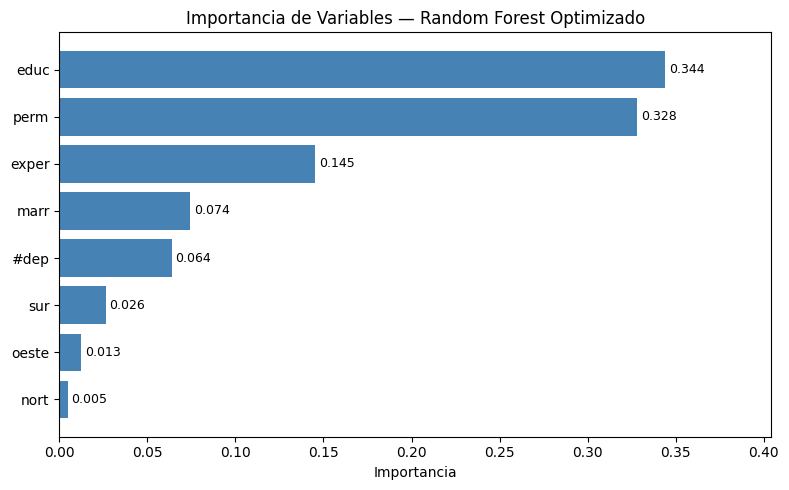

In [14]:
importancias_opt = pd.Series(modelo_rf_opt.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importancias_opt.index, importancias_opt.values, color='steelblue')

# Etiquetas de valor
for bar, val in zip(bars, importancias_opt.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importancia')
ax.set_title('Importancia de Variables — Random Forest Optimizado')
ax.set_xlim(0, importancias_opt.max() + 0.06)
plt.tight_layout()
plt.show()


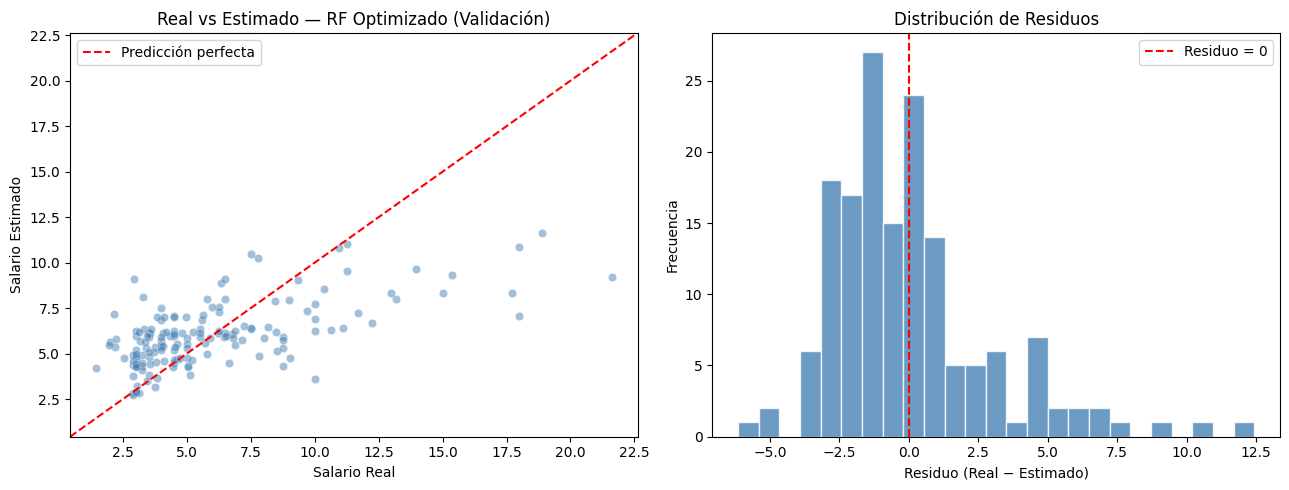

In [15]:
# Predicciones del RF optimizado sobre validación
y_real = y_test.values
y_est  = y_pred_opt_test
residuos = y_real - y_est

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico 1: Real vs Estimado ---
ax1 = axes[0]
ax1.scatter(y_real, y_est, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.4)
lim = [min(y_real.min(), y_est.min()) - 1, max(y_real.max(), y_est.max()) + 1]
ax1.plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
ax1.set_xlabel('Salario Real')
ax1.set_ylabel('Salario Estimado')
ax1.set_title('Real vs Estimado — RF Optimizado (Validación)')
ax1.legend()
ax1.set_xlim(lim)
ax1.set_ylim(lim)

# --- Gráfico 2: Distribución de Residuos ---
ax2 = axes[1]
ax2.hist(residuos, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo = 0')
ax2.set_xlabel('Residuo (Real − Estimado)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Residuos')
ax2.legend()

plt.tight_layout()
plt.show()


## Random Forest — Entrenamiento con toda la base de datos

Se entrena el modelo optimizado usando el dataset completo (526 observaciones) para aprovechar toda la información disponible.


Observaciones usadas: 526
RMSE  : 2.5109
R²    : 0.4971


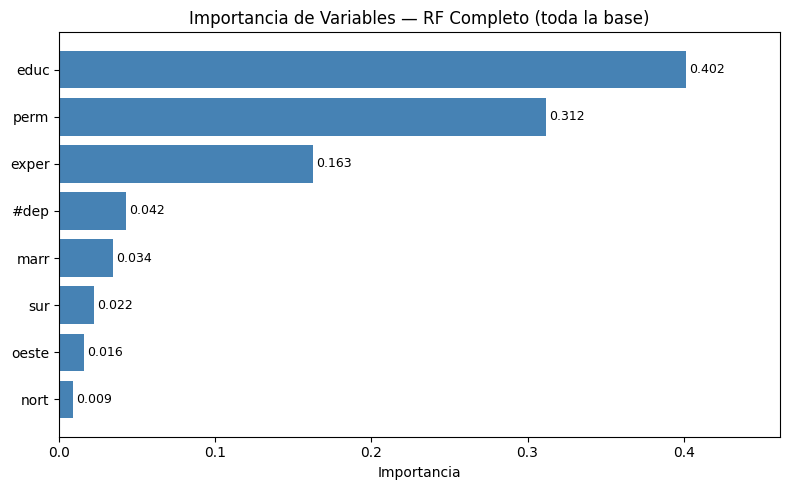

In [16]:
features = ['educ', 'exper', 'perm', 'marr', '#dep', 'nort', 'sur', 'oeste']

X_full = df[features]
y_full = df['salario']

# Entrenar con los hiperparámetros óptimos sobre toda la base
modelo_rf_full = RandomForestRegressor(**search.best_params_, random_state=42)
modelo_rf_full.fit(X_full, y_full)

y_pred_full = modelo_rf_full.predict(X_full)
rmse_full = np.sqrt(mean_squared_error(y_full, y_pred_full))
r2_full   = r2_score(y_full, y_pred_full)

print(f"Observaciones usadas: {len(X_full)}")
print(f"RMSE  : {rmse_full:.4f}")
print(f"R²    : {r2_full:.4f}")

# Importancia de variables
importancias_full = pd.Series(modelo_rf_full.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importancias_full.index, importancias_full.values, color='steelblue')
for bar, val in zip(bars, importancias_full.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importancia')
ax.set_title('Importancia de Variables — RF Completo (toda la base)')
ax.set_xlim(0, importancias_full.max() + 0.06)
plt.tight_layout()
plt.show()


## Predicción sobre Casos Nuevos

Se estiman los salarios de 5 individuos hipotéticos usando el modelo Random Forest entrenado con toda la base.


In [17]:
# Casos hipotéticos
# educ: años de educación | exper: años de experiencia | perm: meses en el trabajo actual
# marr: casado (1/0) | #dep: número de dependientes | nort/sur/oeste: región (1/0)
casos = pd.DataFrame({
    'educ':  [18,  12,   0,  16,   8],
    'exper': [ 5,  20,  42,  10,  30],
    'perm':  [ 0,  24,   6,  12,  60],
    'marr':  [ 0,   1,   1,   0,   1],
    '#dep':  [ 0,   2,   3,   1,   4],
    'nort':  [ 0,   1,   0,   0,   0],
    'sur':   [ 1,   0,   1,   0,   1],
    'oeste': [ 0,   0,   0,   1,   0],
},
index=['Caso 1 (universitario joven)',
       'Caso 2 (técnico con experiencia)',
       'Caso 3 (sin estudios, mayor)',
       'Caso 4 (profesional medio)',
       'Caso 5 (obrero antiguo)'])

casos['Salario Estimado'] = modelo_rf_full.predict(casos[features]).round(2)
casos


,educ,exper,perm,marr,#dep,nort,sur,oeste,Salario Estimado
Caso 1 (universitario joven),18,5,0,0,0,0,1,0,6.83
Caso 2 (técnico con experiencia),12,20,24,1,2,1,0,0,8.85
"Caso 3 (sin estudios, mayor)",0,42,6,1,3,0,1,0,4.54
Caso 4 (profesional medio),16,10,12,0,1,0,0,1,9.94
Caso 5 (obrero antiguo),8,30,60,1,4,0,1,0,6.24
